# Tic Tac Toe Anyone?

Your task this week is to implement an AI agent who plays a perfect (or near perfect) game of an arbitrary sized Tic Tac Toe.

The mechanics of the game have been implemented for you in the [tictactoe.ipynb](./tictactoe.ipynb) notebook.   

This is the only notebook you need to submit when you complete your assignment.

Let's first import all we need before we get started. Make sure you run the code cell below everytime you start working on this notebook.

In [ ]:
%run tictactoe.ipynb
!pip install ipycanvas
import random
import math  # You can use math.inf to initialize to infinity

## A Boring Game?
We'll start by having our agent pick a random move.  
The random algorithm has been implemented for you in the _rand_ function below.
Make sure you run the code cell to define the function.


In [ ]:
def rand(state):
    """
    Generate a random move.
    :param state: GameState object
    :return:  a tuple representing the row column of the random move
    """
    done = False
    while not done:
        row = random.randint(0, state.size - 1)
        col = random.randint(0, state.size - 1)
        if state.available(row,col):
            done = True
    return row, col


You can now execute the code cell below to play and win a Tic Tac Toe game (of any size) against a non-optimal AI agent who picks moves randomly.


In [ ]:
 tictac(6, "rand") # You can change 6 to any positive integer to change the number of rows and columns

As you can see, this is not a challenging game to play.  Your task is to implement an AI agent who will play a better game.

## Minimax
Implement the minimax algorithm by filling in your code in the 4 functions below
 - _minimax_
 - _value_
 - _max_value_
- _min_value_

In [ ]:
def minimax(state):
    """
    Find the best move for our AI agent using the minimax algorithm.
    (searching the entire tree from the current game state)
    :param state: GameState object
    :return:  a tuple representing the row column of the best move
    """
    # Enter your code here and remove the raise statement below
    moves = state.possible_moves()
    return max(moves, key=lambda move: value(state.successor(move, "AI"), "user"))

def value(state, agent):
    """
    Calculate the minimax value for any state under the given agent's
    control.
    :param state: GameState object - state may be terminal or
    non-terminal
    :param agent: (string) 'user' or 'AI' - AI is max
    :return: (integer) value of that state -1, 0 or 1
    """
    # Enter your code here and remove the pass statement below
    if state.is_win("AI"):
        return 1
    if state.is_win("user"):
        return -1
    if state.is_tie():
        return 0

    if agent == "AI":
        return max_value(state)
    else:
        return min_value(state)
    

def max_value(state):
    """
    Calculate the minimax value for a non-terminal state under Max's
    control (AI agent)
    :param state: non-terminal GameState object
    :return: (integer) value of that state -1, 0 or 1
    """
    # Enter your code here and remove the pass statement below
    return max(
        value(state.successor(move, "AI"), "user")
        for move in state.possible_moves()
    )

def min_value(state):
    """
    Calculate the minimax value for a non-terminal state under Min's
    control (user)
    :param state: non-terminal GameState object
    :return: (integer) value of that state -1, 0 or 1
    """
    # Enter your code here and remove the pass statement below
    return min(
        value(state.successor(move, "user"), "AI")
        for move in state.possible_moves()
    )




You can test your minimax code on a 3x3 Tic Tac Toe by running the code cell below.
Make sure your minimax agent is unbeatable.  If you are somehow able to win, that is an indication that your implementation is not correct and you will get no points for this question.

In [ ]:
 tictac(3, "minimax") 

Even though your agent plays a perfect game and cannot be defeated, it searches the entire tree from the current game state to find the best move.    
You can see the total number of nodes evaluated for the game at the bottom. 
For example, 60,694 nodes are evaluated when I play the following game (the numbers on the squares indicate the order in which the squares are played):  
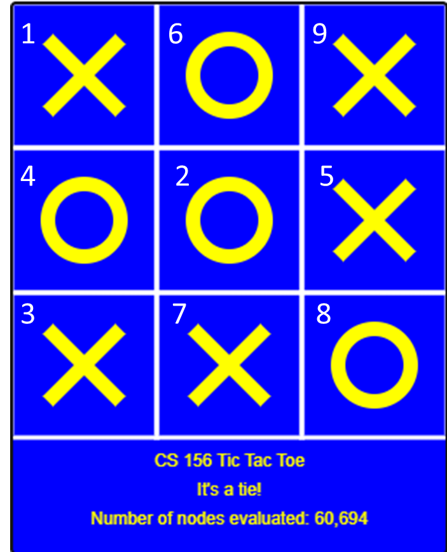

Note that the number of nodes will be different for each game - but of the same order of magnitude (around 60,000).
You can try your minimax agent with a 4x4 Tic Tac Toe but you'll see that it takes too long to decide on a single move. We'll have to do better.

In [ ]:
 tictac(4, "minimax") 

## Minimax with Alpha Beta Pruning
Implement the minimax algorithm with alpha beta pruning by filling in your code in the 4 functions below
 - _alphabeta_
 - _ab_value,_
 - _abmax_value_
- _abmin_value_

In [ ]:
def alphabeta(state):
    """
    Find the best move for our AI agent using the minimax algorithm
    with alpha beta pruning.
    :param state: GameState object
    :return:  a tuple representing the row column of the best move
    """
    # Enter your code here and remove the raise statement below
    moves = state.possible_moves()
    return max(moves, key=lambda move: ab_value(state.successor(move, "AI"), "user", -math.inf, math.inf))

def ab_value(state, agent, alpha, beta):
    """
    Calculate the minimax value for any state under the given agent's
    control using alpha beta pruning
    :param state: GameState object - state may be terminal or
    non-terminal.
    :param agent: (string) 'user' or 'AI' - AI is max
    :return: (integer) value of that state -1, 0 or 1
    """
    # Enter your code here and remove the pass statement below
    if state.is_win("AI"):
        return 1
    if state.is_win("user"):
        return -1
    if state.is_tie():
        return 0
    if agent == "AI":
        return abmax_value(state, alpha, beta)
    else:
        return abmin_value(state, alpha, beta)

def abmax_value(state, alpha, beta):
    """
    Calculate the minimax value for a non-terminal state under Max's
    control (AI agent) using alpha beta pruning
    :param state: non-terminal GameState object
    :return: (integer) value of that state -1, 0 or 1
    """
    # Enter your code here and remove the pass statement below
    v = -math.inf
    for move in state.possible_moves():
        v = max(v, ab_value(state.successor(move, "AI"), "user", alpha, beta))
        if v >= beta:
            return v
        alpha = max(alpha, v)
    return v


def abmin_value(state, alpha, beta):
    """
    Calculate the minimax value for a non-terminal state under Min's
    control (user) using alpha beta pruning
    :param state: non-terminal GameState object
    :return: (integer) value of that state -1, 0 or 1
    """
    # Enter your code here and remove the pass statement below
    v = math.inf
    for move in state.possible_moves():
        v = min(v, ab_value(state.successor(move, "user"), "AI", alpha, beta))
        if v <= alpha:
            return v
        beta = min(beta, v)
    return v


 You can test your Alpha Beta  code on a 3x3 Tic Tac Toe:

In [ ]:
tictac(3, "alphabeta")

**Make sure that your agent is still unbeatable.  If you are somehow able to win, that is an indication that your implementation is not correct.**
You will see that the game is much faster now and the number of nodes expanded has been significantly reduced.  
Only 4,423 nodes should be expanded when we play the game shown above (as opposed to 60,694 nodes evaluated with minimax without alpha beta pruning.  
However we are still unable to play a 4x4 Tic Tac Toe.

In [ ]:
tictac(4, "alphabeta")


## Depth Limit with Alpha Beta Pruning
Implement a depth limited alpha beta algorithm by filling in your code in the 4 functions below
 - _abdl_
 - _abdl_value,_
 - _abdlmax_value_
- _abdlmin_value_

You can use the evaluation function that has been implemented for you in the [tictactoe.ipynb](./tictactoe.ipynb) notebook  (the _eval_ method in GameState class) to evaluate non terminal nodes.  However for the terminal nodes (win, tie and lose) you will have to decide on values that are **consistent** with the values retuned by _eva_l.  Make sure you understand what _eval_ is doing first.

In [ ]:
def abdl(state, depth):
    """
    Find the best move for our AI agent by limiting the alpha beta
    search the given depth and using the evaluation function
    state.eval()
    :param state: GameState object
    :return:  a tuple representing the row column of the best move
    """
    # Enter your code here and remove the raise statement below
    moves = state.possible_moves()
    return max(moves, key=lambda move: abdl_value(state.successor(move, "AI"), "user", -math.inf, math.inf, depth - 1))

def abdl_value(state, agent, alpha, beta, depth):
    """
    Calculate the utility for any state under the given agent's control
    using depth limited alpha beta pruning and the evaluation
    function state.eval()
    :param state: GameState object - state may be terminal or
    non-terminal
    :param agent: (string) 'user' or 'AI' - AI is max
    :return: (integer) utility of that state
    """
    # Enter your code here and remove the pass statement below
    terminal_score = 2 * state.size + 3
    
    if state.is_win("AI"):
        return terminal_score
    if state.is_win("user"):
        return -terminal_score
    if state.is_tie():
        return 0
    if depth == 0:
        return state.eval()
    if agent == "AI":
        return abdlmax_value(state, alpha, beta, depth)
    else:
        return abdlmin_value(state, alpha, beta, depth)


def abdlmax_value(state, alpha, beta, depth):
    """
    Calculate the utility for a non-terminal state under Max's control
    using depth limited alpha beta pruning and the evaluation
    function state.eval()
    :param state: non-terminal GameState object
    :return: (integer) utility (evaluation function) of that state
    """
    # Enter your code here and remove the pass statement below
    v = -math.inf
    for move in state.possible_moves():
        v = max(v, abdl_value(state.successor(move, "AI"), "user", alpha, beta, depth - 1))
        if v >= beta:
            return v
        alpha = max(alpha, v)
    return v


def abdlmin_value(state, alpha, beta, depth):
    """
    Calculate the utility for a non-terminal state under Min's control
    using depth limited alpha beta pruning and the evaluation
    function state.eval()
    :param state: non-terminal GameState object
    :return: (integer) utility (evaluation function) of that state
    """
    # Enter your code here and remove the pass statement below
    v = math.inf
    for move in state.possible_moves():
        v = min(v, abdl_value(state.successor(move, "user"), "AI", alpha, beta, depth - 1))
        if v <= alpha:
            return v
        beta = min(beta, v)
    return v



You can test your implementation  code on a 4x4 Tic Tac Toe and with a depth of 6 below:

In [ ]:
tictac(4, "abdl", 6)

906,958 nodes are evaluated when I play the following game (the numbers on the squares indicate the order in which the squares are played):
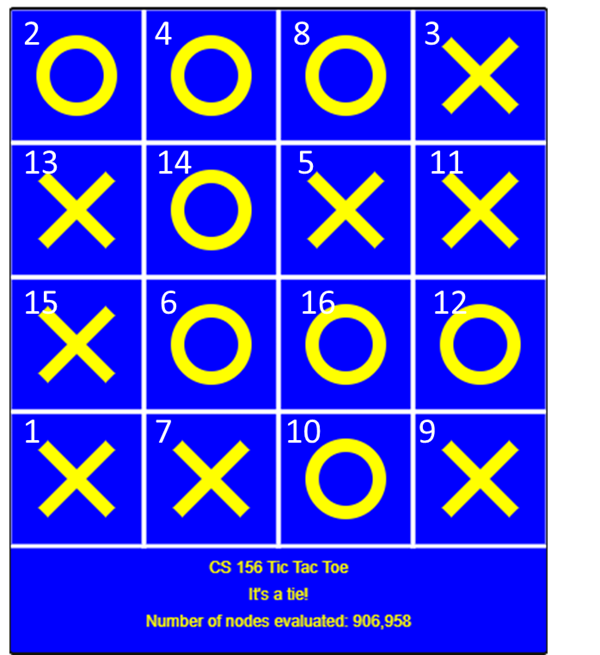

You will find that your agent is still unbeatable.  You can even test your implementation on a 7x7 Tic Tac Toe with a depth of 3 as follows:


In [ ]:
tictac(7, "abdl", 3)

For a game of size 3, what depth do you have to go down to to beat your abdl agent?   
Hint:  start at depth 6, then 5 ...

In [ ]:
tictac(3, "abdl",6)

In [ ]:
tictac(3, "abdl",5)

In [ ]:
tictac(3, "abdl",5)

In [ ]:
tictac(3, "abdl",4)

In [ ]:
tictac(3, "abdl",3)

In [ ]:
tictac(3, "abdl",2)

In [ ]:
tictac(3, "abdl",1)

Your answer: **Depth 5.**